# Tracé des POE des EETCs qui ne sont pas forçement des compounds

C'est à dire que l'on ne fait pas de ranking avec le produit de deux métriques en amont, on inclue dans le plot de chacune des métriques les ETCs qui sont des extrêmes dans une variable, mais pas forcément dans l'autre. Ainsi, il y'a davantage d'ETCs qu'il n'y a de points dans le scatter plot de la sélection des EETCs. En réalité, il y'apeu de différence, seulement pour les EETCs les plus faibles, mais ceux qui sont un peu plus extrêmes sont tous des compounds.

In [17]:
import pandas as pd
from glob import glob
from braceexpand import braceexpand
import numpy as np
import matplotlib.pyplot as plt
import pickle
import xarray as xr
from scipy.stats import gaussian_kde
from matplotlib.ticker import ScalarFormatter
import sys
import os
from matplotlib.lines import Line2D
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'POSTPROCESSING')))
from ETC_tools import calculate_ranking, open_files
from matplotlib.ticker import AutoMinorLocator
import matplotlib.ticker as ticker

## Introduction

### Déclaration des variables

In [18]:
simulations = ['UBD', 'UBE', 'UBF', 'UBG', 'UBH', 'UBI']
sim_hist_fut = {'UBD': 'UBG', 'UBE': 'UBH', 'UBF': 'UBI'}

quantile = 0.999
future = True #only ETCs after 2066 will be retained for future simulations. Also, ETCs prior 1980 are not retained for historical ones.
method = 'ratio' #How the metrics have been calculated (diff or ratio)
if method == 'ratio':
    thr_value = 1.
elif method == 'diff':
    thr_value = 0.

### Ouverture des fichiers

In [19]:
EETC_dict = {}
df = {}

for sim in simulations:        
    df_sim, EETC_dict_sim = open_files(sim, future=future)
    
    EETC_dict[sim] = EETC_dict_sim
    df[sim] = df_sim

### We associate the date at which the pressure was minimum for each extreme ETCs of the dict, to later do a seasonal discrimation

In [20]:
metrics = ['cum_precip', 'cum_avg_precip', 'cum_wind', 'cum_avg_wind']
for sim in simulations:
    for storm in EETC_dict[sim]:
        if (
            any(EETC_dict[sim][storm][m].sel(quantile=quantile).values > thr_value for m in metrics)
            or (EETC_dict[sim][storm]['SSI'].sel(quantile=quantile).values != 0)
        ):
            storm_group = df[sim].groupby('storm').get_group(storm)
            min_pressure_row = storm_group.loc[storm_group['pressure'].idxmin()]
            EETC_dict[sim][storm]['min_pressure_date'] = min_pressure_row['date']

### Paramètres utile pour les plots

In [21]:
plot_params = [
    {
        "var": "cum_precip",
        # "label": '$ETC_{PR,cum}|_{QC}$ [mm]',
        "label": '$ETC_{PR,cum}|_{QC}$ [%]',
        "ax_index": (0, 0)
    },
    {
        "var": "cum_avg_precip",
        # "label": '$\overline{{ETC}_{PR}|_{QC}}$ [mm.h$^{{-1}}$]',
        "label": '$\overline{{ETC}_{PR}|_{QC}}$ [%]',
        "ax_index": (0, 1)
    },
    # {
    #     "var": "SSI",
    #     "label": '$SSI$',
    #     "ax_index": (1, 0)
    # },
    {
        "var": "cum_wind",
        # "label": '$ETC_{WS,cum}|_{QC}$ [km.h$^{{-1}}$]',
        "label": '$ETC_{WS,cum}|_{QC}$ [%]',
        "ax_index": (1, 0)
    },
    {
        "var": "cum_avg_wind",
        # "label": '$\overline{{ETC}_{WS}|_{QC}}$ [km.h$^{{-1}}$]',
        "label": '$\overline{{ETC}_{WS}|_{QC}}$ [%]',
        "ax_index": (1, 1)
    }
]

sim_linestyles = {
    'UBD': '-',
    'UBE': ':',
    'UBF': '--',
    'UBG': '-',
    'UBH': ':',
    'UBI': '--',
}

sim_label = {
    'UBD': 'EC-Earth 1980-2015',
    'UBE': 'MPI 1980-2015',
    'UBF': 'MIROC 1980-2015',
    'UBG': 'EC-Earth 2065-2100',
    'UBH': 'MPI 2065-2100',
    'UBI': 'MIROC 2065-2100',
}

change_label = {
    'UBD': 'EC-Earth3-Veg',
    'UBE': 'MPI-ESM1-2-HR',
    'UBF': 'MIROC6',
}

sim_color = {
    'UBD': '#1f77b4',
    'UBE': '#ff7f0e',
    'UBF': '#2ca02c',
    'UBG': '#1f77b4',
    'UBH': '#ff7f0e',
    'UBI': '#2ca02c',
}

seasons = {'DJF': [12, 1, 2], 'MAM': [3, 4, 5], 'JJA': [6, 7, 8], 'SON': [9, 10, 11]}

season_color = {'DJF': '#7eb7de', 'MAM': '#2ca02c', 'JJA': '#ff7f0e', 'SON': '#d62728'}

def clean_log_format(x, pos):
    if x >= 1 and x == int(x):
        return str(int(x))  # Affiche 1, 10, 100
    elif x < 1:
        return f"{x:.1g}"   # Par exemple : 0.1
    else:
        return str(x)

## Tracé des plots

### Distribution des EETCs au Québec Sud sous forme de PoE

#### PoE historique vs future échelle log

Text(0.5, 0.98, 'Probability of Exceedance of the strongest ETCs over Québec — $99.9^{th}$ percentile')

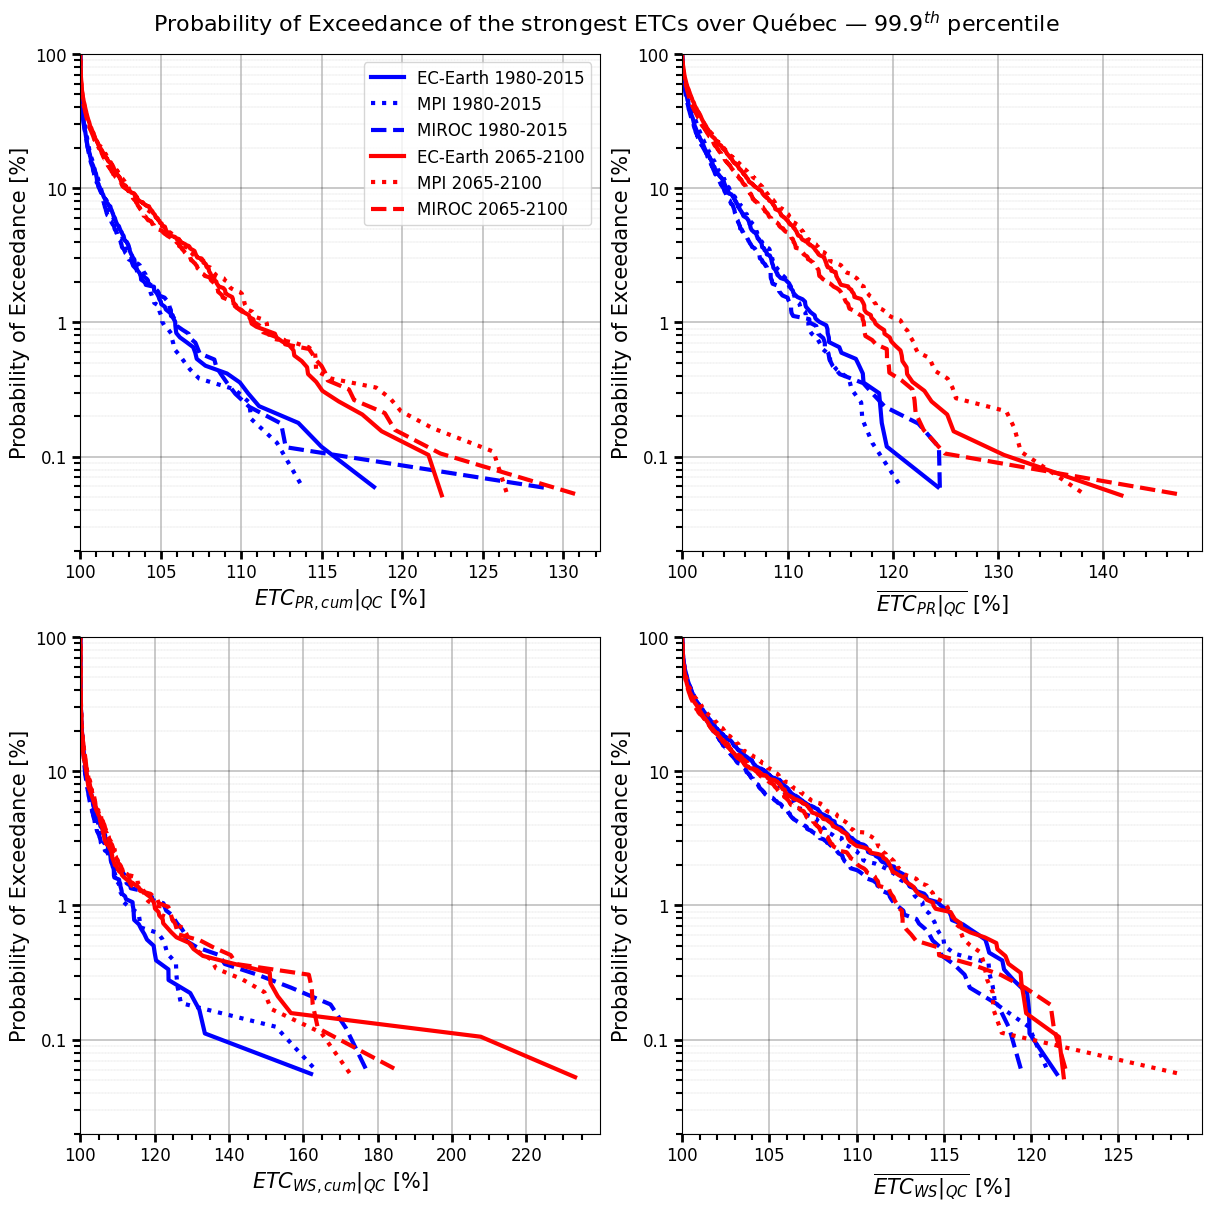

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

for params in plot_params:
    ax = axes[params["ax_index"]]
    
    for isim, sim in enumerate(simulations):
   
        EETCs_var = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
        ]
            
        # Sort values for probability of exceedance
        sorted_vals = np.sort(EETCs_var)[::-1]  # Sort in descending order
        prob_exceedance = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)  # Calculate exceedance probability

        if sim in sim_hist_fut:
            color = 'blue'
        else:
            color = 'red'
        
        ax.plot(sorted_vals * 100, prob_exceedance * 100, color=color, linestyle=sim_linestyles[sim], label=sim_label[sim], linewidth=3)

    ax.set_xlim(100, None)
    # ax.set_ylim(-1.3, 2)  # Set y-axis limits to stop at 10^0
    ax.set_ylim(0.02, 100)  # Set y-axis limits to stop at 10^0
    ax.set_yscale('log')  # Set y-axis to logarithmic scale
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    ax.set_xlabel(params["label"], fontsize=15)
    ax.set_ylabel("Probability of Exceedance [%]", fontsize=15)
    # ax.set_title(params["label"], fontsize=15)
    if params["ax_index"] == (0, 0): ax.legend(fontsize=12, loc='upper right')
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.minorticks_on()
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')
    ax.grid(True, which='minor', axis='y', linestyle='--', linewidth=0.2)

fig.suptitle(f"Probability of Exceedance of the strongest ETCs over Québec — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)

#### PoE historique vs future échelle linéaire

Text(0.5, 0.98, 'Probability of Exceedance of the strongest ETCs over Québec — $99.9^{th}$ percentile')

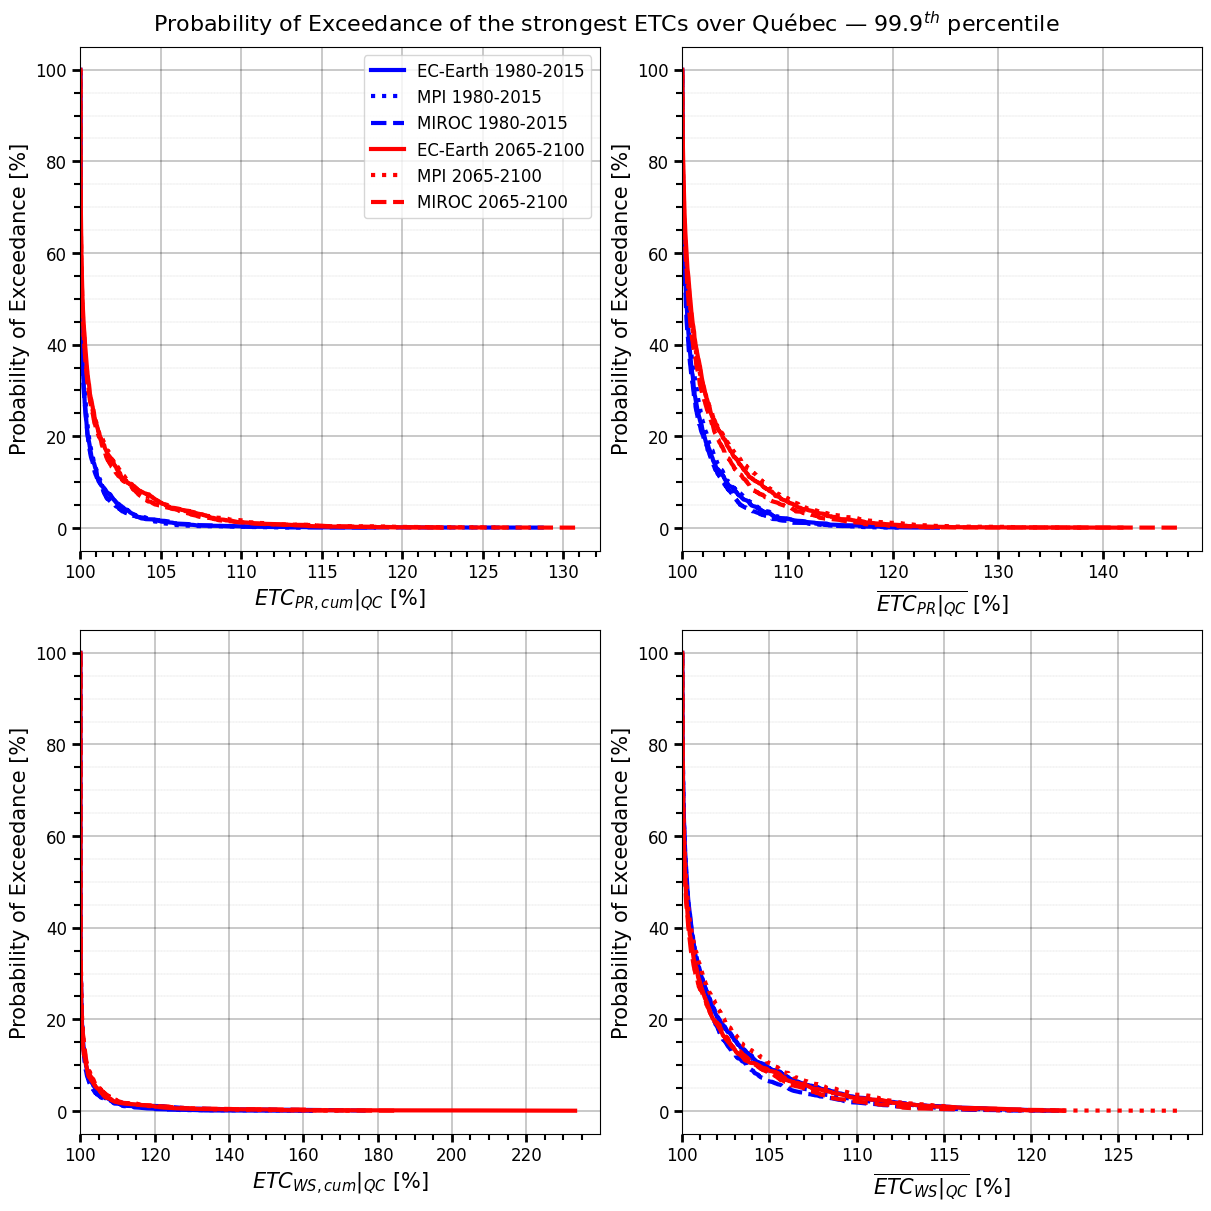

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

for params in plot_params:
    ax = axes[params["ax_index"]]
    
    for isim, sim in enumerate(simulations):
   
        EETCs_var = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
        ]
            
        # Sort values for probability of exceedance
        sorted_vals = np.sort(EETCs_var)[::-1]  # Sort in descending order
        prob_exceedance = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)  # Calculate exceedance probability
        
        if sim in sim_hist_fut:
            color = 'blue'
        else:
            color = 'red'
            
        ax.plot(sorted_vals * 100, prob_exceedance * 100, color=color, linestyle=sim_linestyles[sim], label=sim_label[sim], linewidth=3)

    ax.set_xlim(100, None)
    # ax.set_ylim(-1.3, 2)  # Set y-axis limits to stop at 10^0
    # ax.set_ylim(0.02, 100)  # Set y-axis limits to stop at 10^0
    # ax.set_yscale('log')  # Set y-axis to logarithmic scale
    # ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    # ax.yaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    ax.set_xlabel(params["label"], fontsize=15)
    ax.set_ylabel("Probability of Exceedance [%]", fontsize=15)
    # ax.set_title(params["label"], fontsize=15)
    if params["ax_index"] == (0, 0): ax.legend(fontsize=12, loc='upper right')
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.minorticks_on()
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')
    ax.grid(True, which='minor', axis='y', linestyle='--', linewidth=0.2)

fig.suptitle(f"Probability of Exceedance of the strongest ETCs over Québec — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)

#### Changement dans le futur du seuil des métriques en fonction de la PoE

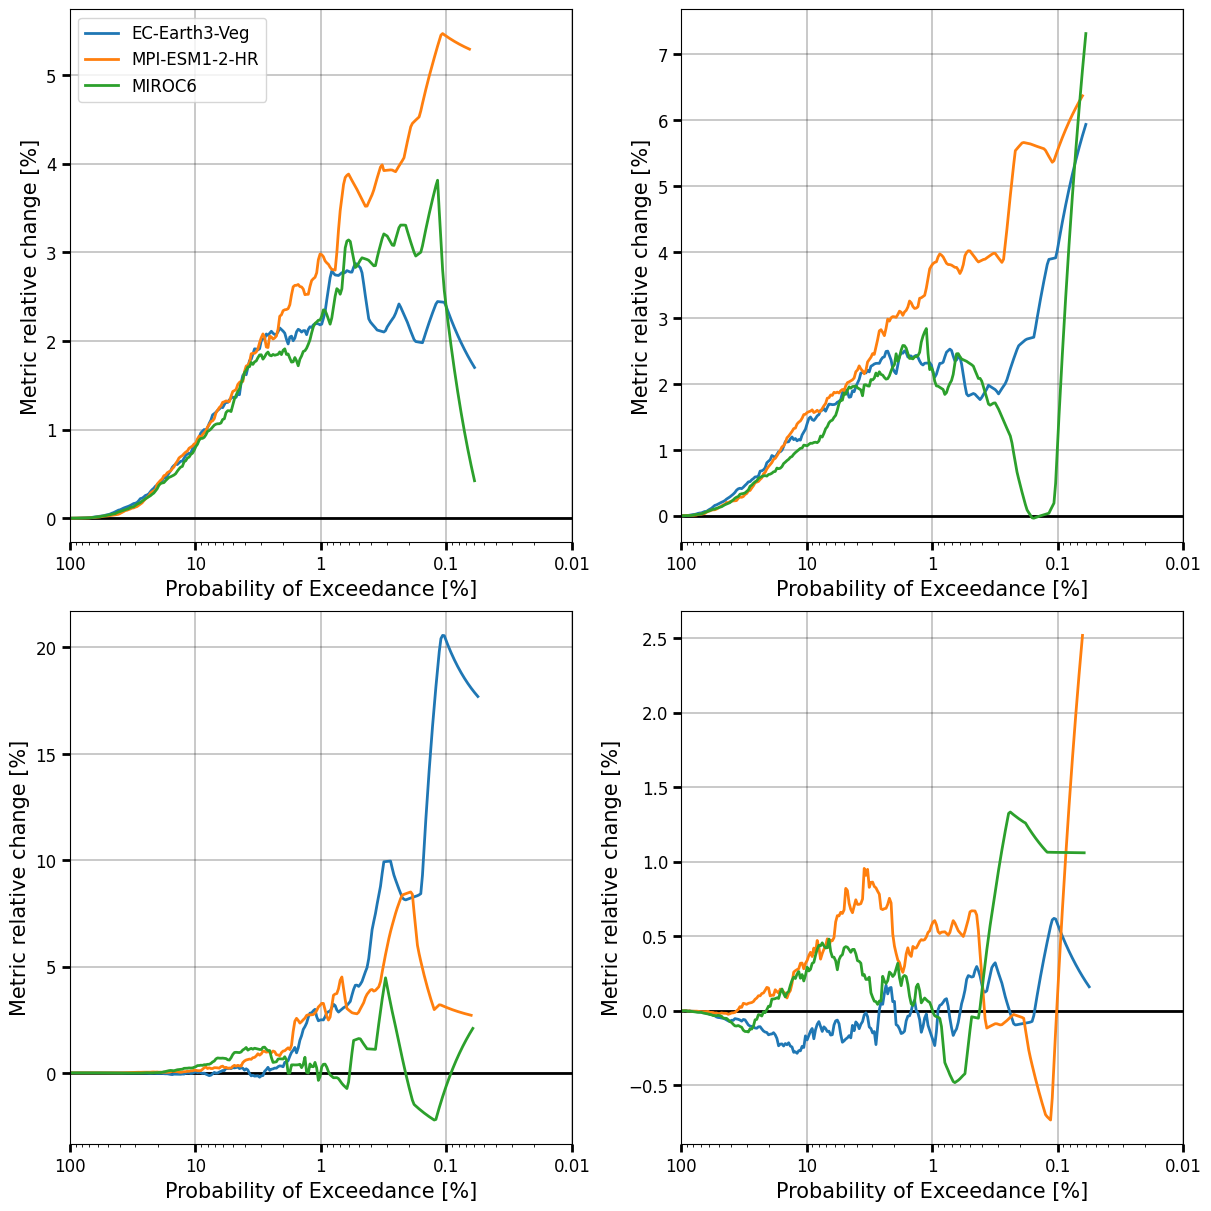

In [24]:
common_poe = np.logspace(np.log10(0.01), np.log10(100), 300)

fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

for params in plot_params:
    
    ax = axes[params["ax_index"]]
    ax.axhline(y=0, color='k', lw=2)
    
    for isim, sim in enumerate(sim_hist_fut):
        
        EETCs_hist = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
        ]
        
        EETCs_fut = [
            EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim_hist_fut[sim]]
            if EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
        ]

        # Trie les valeurs
        EETCs_hist_sorted = np.sort(EETCs_hist)[::-1]
        EETCs_fut_sorted = np.sort(EETCs_fut)[::-1]

        # Calcule les poe correspondants
        poe_hist = 100 * (np.arange(1, len(EETCs_hist_sorted) + 1) / len(EETCs_hist_sorted))
        poe_fut = 100 * (np.arange(1, len(EETCs_fut_sorted) + 1) / len(EETCs_fut_sorted))

        # Interpole sur la grille commune
        interp_hist = np.interp(common_poe, poe_hist, EETCs_hist_sorted, left=np.nan, right=np.nan)
        interp_fut = np.interp(common_poe, poe_fut, EETCs_fut_sorted, left=np.nan, right=np.nan)

        # Calcule la différence (futur - historique)
        diff = 100 * (interp_fut - interp_hist) / (interp_fut + interp_hist)

        ax.plot(common_poe, diff, label=change_label[sim], color=sim_color[sim], linewidth=2)
        
    ax.set_xlabel("Probability of Exceedance [%]", fontsize=15)
    ax.set_xlim(100, 0.01)
    ax.set_xscale('log')
    ax.set_ylabel("Metric relative change [%]", fontsize=15)
    # ax.set_ylim(-0, 0.3)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    if params["ax_index"] == (0, 0): ax.legend(fontsize=12, loc='best')
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')

# plt.savefig('/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/POE_diff_UBD_fut_vs_hist_season.png', dpi=70, bbox_inches='tight', transparent=True)

/home/vdemeyer/py3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


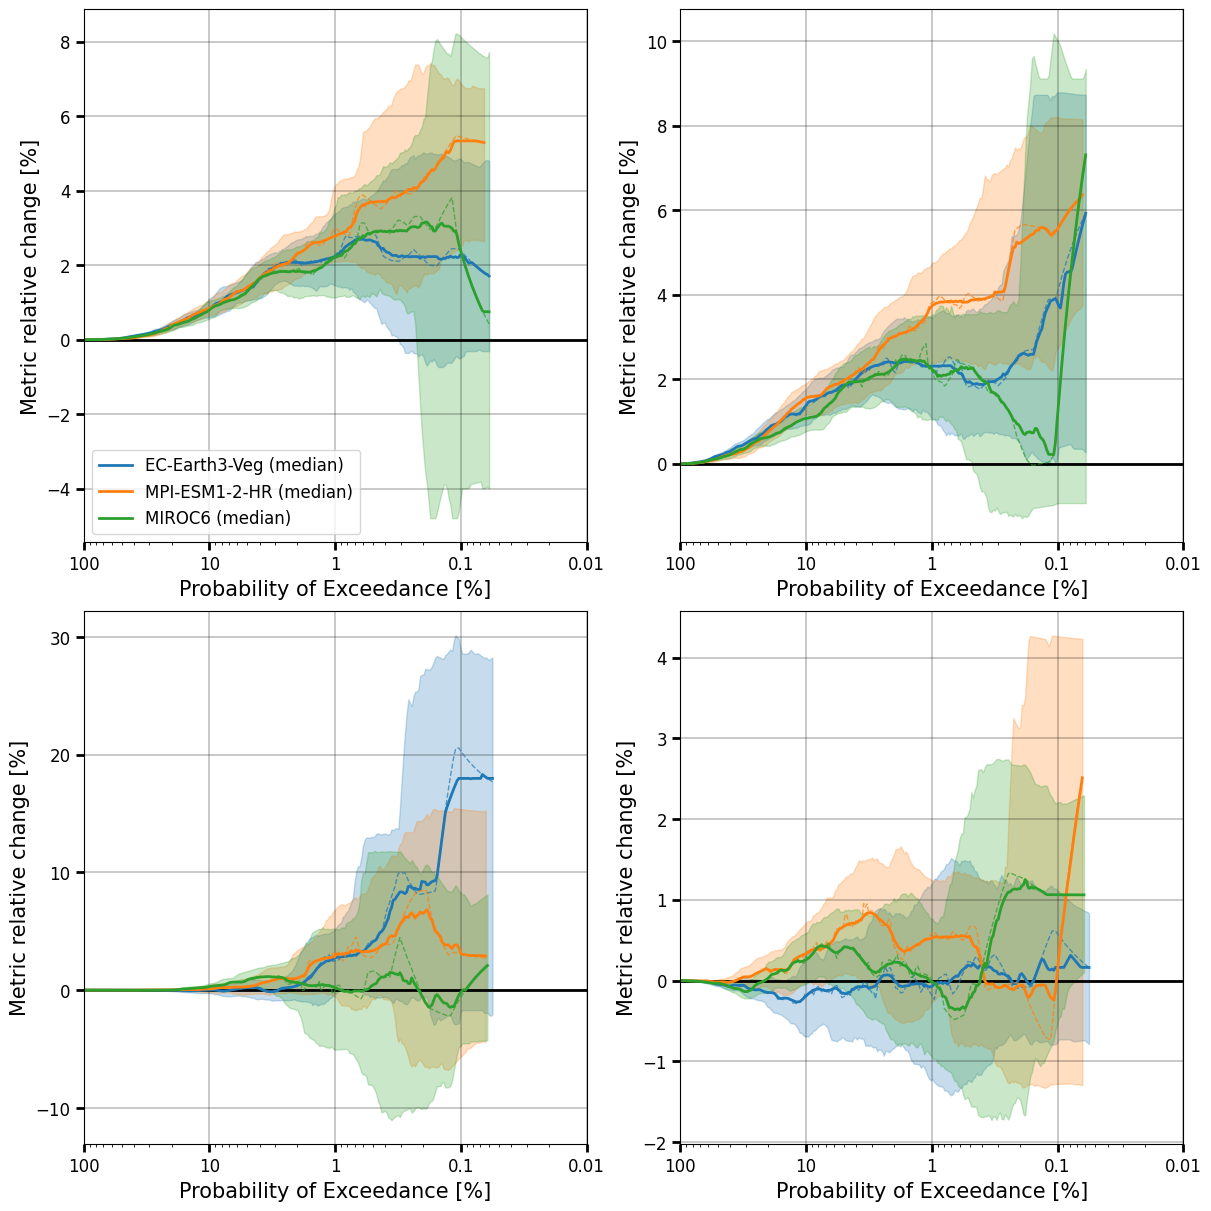

In [25]:
# --- paramètres bootstrap ---
nboot = 1000  # augmente si tu veux des CI plus lisses
ci_lower = 2.5
ci_upper = 97.5

fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

for params in plot_params:
    
    ax = axes[params["ax_index"]]
    ax.axhline(y=0, color='k', lw=2)
    
    for isim, sim in enumerate(sim_hist_fut):
        
        # --- récupère les valeurs par cyclone (comme toi) ---
        EETCs_hist = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
        ]
        
        EETCs_fut = [
            EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim_hist_fut[sim]]
            if EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
        ]

        # si vide -> skip
        if len(EETCs_hist) == 0 or len(EETCs_fut) == 0:
            print(f"Warning: pas d'EETC pour {sim} ou {sim_hist_fut[sim]} et var {params['var']}")
            continue

        # Trie les valeurs (descendant)
        EETCs_hist_sorted = np.sort(np.asarray(EETCs_hist))[::-1]
        EETCs_fut_sorted = np.sort(np.asarray(EETCs_fut))[::-1]

        # poe observés
        poe_hist = 100 * (np.arange(1, len(EETCs_hist_sorted) + 1) / len(EETCs_hist_sorted))
        poe_fut  = 100 * (np.arange(1, len(EETCs_fut_sorted) + 1) / len(EETCs_fut_sorted))

        # interp sur grille commune
        interp_hist = np.interp(common_poe, poe_hist, EETCs_hist_sorted, left=np.nan, right=np.nan)
        interp_fut  = np.interp(common_poe, poe_fut,  EETCs_fut_sorted,  left=np.nan, right=np.nan)

        # diff observée (ta formule, en % relatif)
        diff_obs = 100 * (interp_fut - interp_hist) / (interp_fut + interp_hist)

        # ----------------------
        # BOOTSTRAP (pointwise)
        # ----------------------
        boot_changes = np.full((nboot, common_poe.size), np.nan)

        n_hist = len(EETCs_hist_sorted)
        n_fut  = len(EETCs_fut_sorted)

        for ib in range(nboot):
            # resample indices avec remise (cyclones entiers)
            idx_hist = np.random.randint(0, n_hist, size=n_hist)
            idx_fut  = np.random.randint(0, n_fut,  size=n_fut)

            h_b = np.sort(np.asarray(EETCs_hist_sorted)[idx_hist])[::-1]
            f_b = np.sort(np.asarray(EETCs_fut_sorted)[idx_fut])[::-1]

            poe_h_b = 100 * (np.arange(1, len(h_b) + 1) / len(h_b))
            poe_f_b = 100 * (np.arange(1, len(f_b) + 1) / len(f_b))

            interp_h_b = np.interp(common_poe, poe_h_b, h_b, left=np.nan, right=np.nan)
            interp_f_b = np.interp(common_poe, poe_f_b, f_b, left=np.nan, right=np.nan)

            # calcule diff bootstrap (même formule)
            diff_b = 100 * (interp_f_b - interp_h_b) / (interp_f_b + interp_h_b)

            boot_changes[ib, :] = diff_b

        # percentiles pointwise en tolérant NaN (zones trop rares resteront NaN)
        lower = np.nanpercentile(boot_changes, ci_lower, axis=0)
        median = np.nanpercentile(boot_changes, 50, axis=0)
        upper = np.nanpercentile(boot_changes, ci_upper, axis=0)

        # plot: bande CI (masque les NaN) puis médiane et courbe observée
        valid = (~np.isnan(lower)) & (~np.isnan(upper))
        label = change_label[sim]

        if np.any(valid):
            ax.fill_between(common_poe[valid], lower[valid], upper[valid], alpha=0.25, color=sim_color[sim])
            ax.plot(common_poe, median, linewidth=2, color=sim_color[sim], label=label + ' (median)')
        # plot de ta courbe observée (optionnel: en trait noir pointillé)
        ax.plot(common_poe, diff_obs, lw=1, color=sim_color[sim], linestyle='--', alpha=0.7)

        # Optionnel: indiquer le nombre d'événements supportant chaque poe (aide à interpréter CI)
        # on peut tracer en gris en bas ; ici on calcule un "support" = min(n_hist, n_fut) interpolé
        # support = np.minimum(
        #     np.interp(common_poe, poe_hist, np.arange(1, len(EETCs_hist_sorted)+1), left=0, right=0),
        #     np.interp(common_poe, poe_fut,  np.arange(1, len(EETCs_fut_sorted)+1),  left=0, right=0)
        # )
        # # trace un petit pseudo-axe (facultatif)
        # ax2 = ax.twinx()
        # ax2.plot(common_poe, support, linestyle='-', linewidth=0.5, alpha=0.3)
        # ax2.set_ylim(0, max(support) if max(support)>0 else 1)
        # ax2.set_yticks([])  # cacher ticks; si tu veux montrer légende, adapte
        # ax2.set_zorder(ax.get_zorder()-1)
        # ax2.patch.set_alpha(0)

    ax.set_xlabel("Probability of Exceedance [%]", fontsize=15)
    ax.set_xlim(100, 0.01)
    ax.set_xscale('log')
    ax.set_ylabel("Metric relative change [%]", fontsize=15)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    if params["ax_index"] == (0, 0): ax.legend(fontsize=12, loc='lower left')
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')

plt.show()

#### Changement dans le futur de la probabilité d'excéder un seuil de métrique

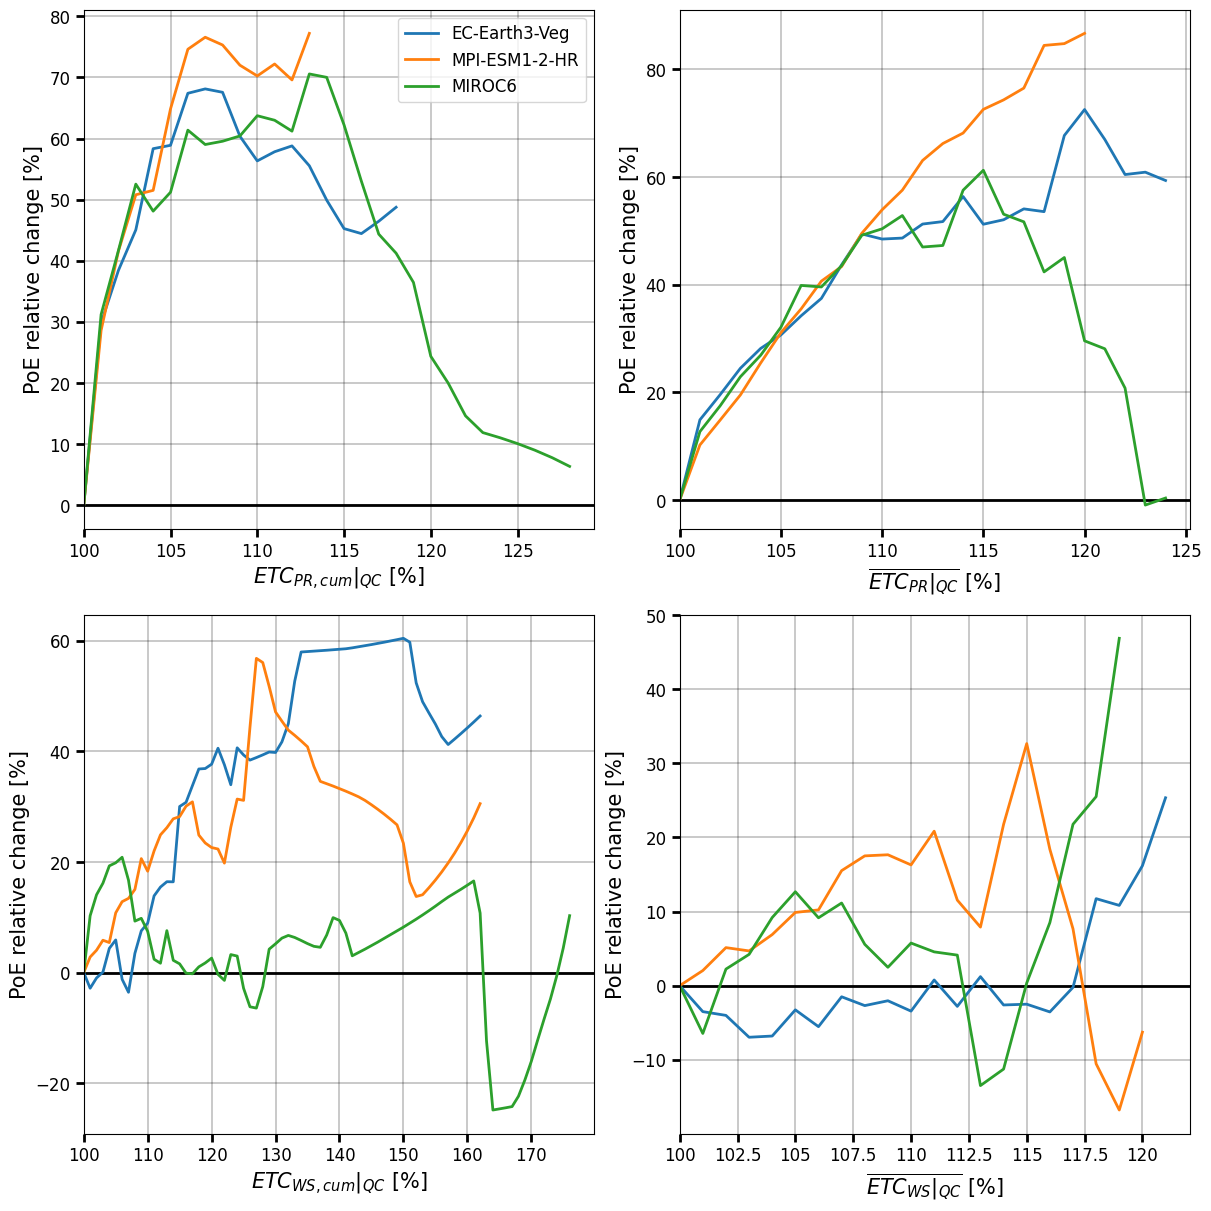

In [26]:
common_metric_value = np.arange(thr_value, 5, 0.01)

fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

for params in plot_params:
    
    ax = axes[params["ax_index"]]
    ax.axhline(y=0, color='k', lw=2)
    
    for isim, sim in enumerate(sim_hist_fut):
        
        EETCs_hist = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
        ]
        
        EETCs_fut = [
            EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim_hist_fut[sim]]
            if EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
        ]

        # Trie les valeurs
        EETCs_hist_sorted = np.sort(EETCs_hist)#[::-1]
        EETCs_fut_sorted = np.sort(EETCs_fut)#[::-1]

        # Calcule les poe correspondants
        poe_hist = 100 * (np.arange(1, len(EETCs_hist_sorted) + 1) / len(EETCs_hist_sorted))
        poe_fut = 100 * (np.arange(1, len(EETCs_fut_sorted) + 1) / len(EETCs_fut_sorted))
        
        poe_hist = poe_hist[::-1] #interp nécessite une grille croissante (EETCs_hist_sorted et common_metric_value), donc j'inverse l'ordre de tout, dont les POE
        poe_fut = poe_fut[::-1]

        # Interpole sur la grille commune
        interp_hist = np.interp(common_metric_value, EETCs_hist_sorted, poe_hist, right=np.nan)
        interp_fut = np.interp(common_metric_value, EETCs_fut_sorted, poe_fut, right=np.nan)

        # interp_hist = interp_hist
        # interp_fut  = interp_fut

        # Calcule la différence (futur - historique)
        diff = 100 * (interp_fut - interp_hist) / (interp_fut + interp_hist)

        ax.plot(common_metric_value * 100, diff, label=change_label[sim], linewidth=2, color=sim_color[sim])
        
    ax.set_xlabel(params["label"], fontsize=15)
    ax.set_xlim(100, None)
    # ax.set_xscale('log')
    ax.set_ylabel("PoE relative change [%]", fontsize=15)
    # ax.set_ylim(-0, 0.3)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    if params["ax_index"] == (0, 0): ax.legend(fontsize=12, loc='best')
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')

# plt.savefig('/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/POE_diff_UBD_fut_vs_hist_season.png', dpi=70, bbox_inches='tight', transparent=True)

### Plots saisonniers

#### EC-Earth3-Veg

##### PoE historique vs future échelle log

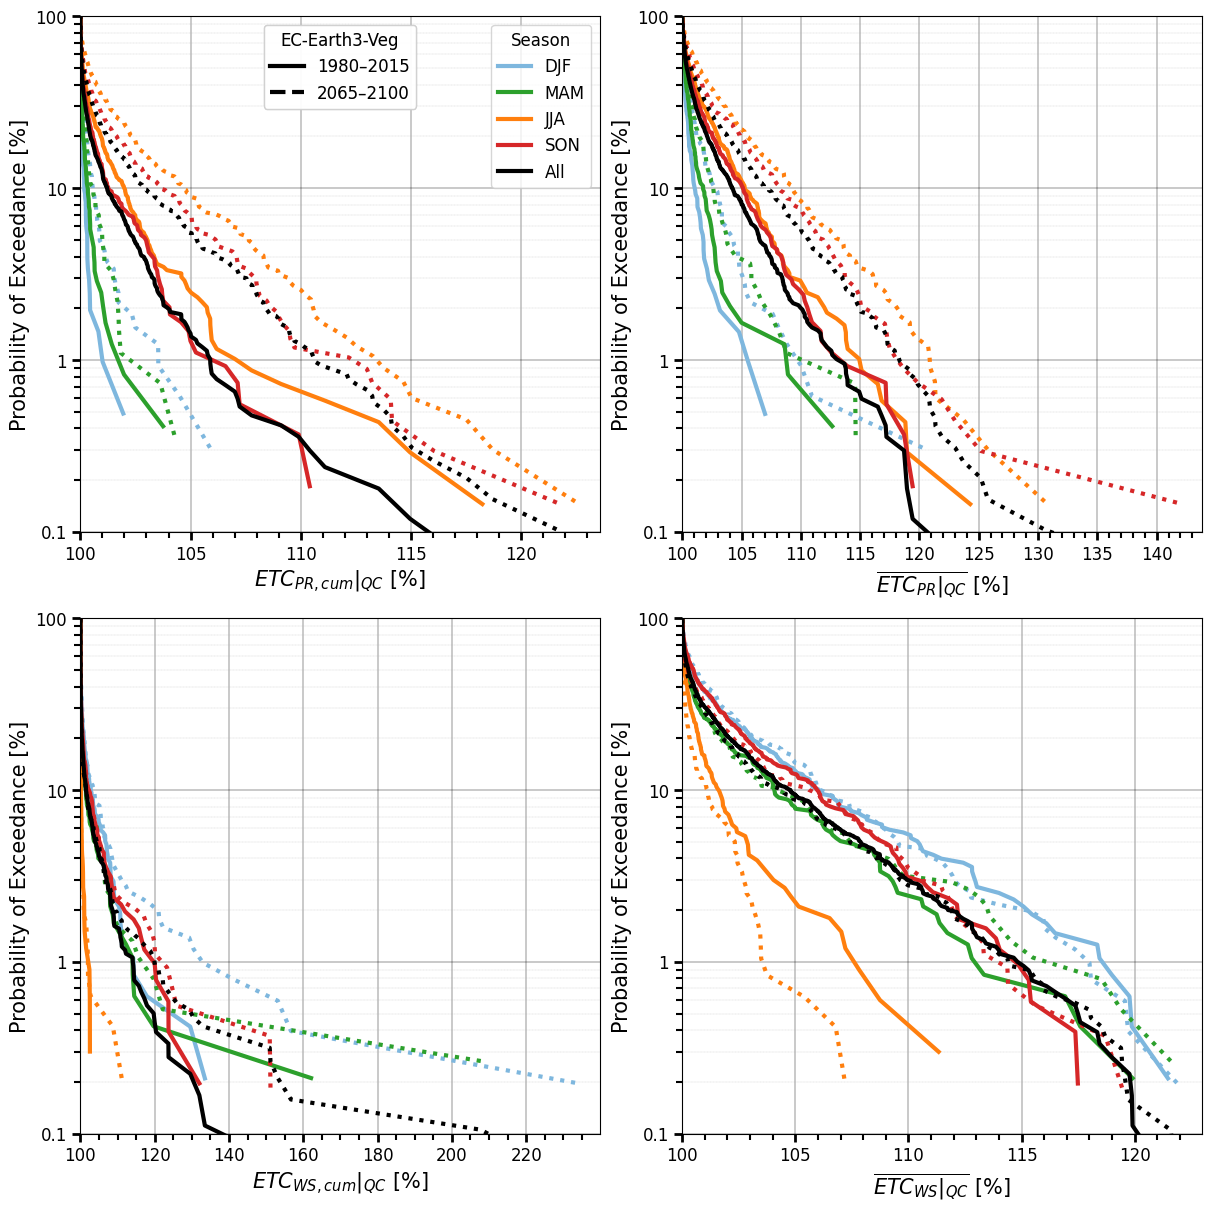

In [27]:
sim = 'UBD'
title = 'EC-Earth3-Veg'

fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

for params in plot_params:
    ax = axes[params["ax_index"]]
                
    for season, months in seasons.items():

        EETCs_hist = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if (
                EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim][k]['min_pressure_date']).month in months
            )
        ]
        EETCs_fut = [
            EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim_hist_fut[sim]]
            if (
                EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim_hist_fut[sim]][k]['min_pressure_date']).month in months
            )
        ]

        # Sort values for probability of exceedance
        sorted_vals_hist = np.sort(EETCs_hist)[::-1]  # Sort in descending order
        sorted_vals_fut  = np.sort(EETCs_fut)[::-1]
        
        prob_exceedance_hist = np.arange(1, len(sorted_vals_hist) + 1) / len(sorted_vals_hist)  # Calculate exceedance probability
        prob_exceedance_fut  = np.arange(1, len(sorted_vals_fut) + 1) / len(sorted_vals_fut)
        
        ax.plot(sorted_vals_hist * 100, prob_exceedance_hist * 100, color=season_color[season], linestyle='-', label=None, linewidth=3)
        ax.plot(sorted_vals_fut * 100, prob_exceedance_fut * 100, color=season_color[season], linestyle=':', label=None, linewidth=3)
  
    EETCs_hist = [
        EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
        for k in EETC_dict[sim]
        if EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
    ]
    EETCs_fut = [
        EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
        for k in EETC_dict[sim_hist_fut[sim]]
        if EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
    ]

    # Sort values for probability of exceedance
    sorted_vals_hist = np.sort(EETCs_hist)[::-1]  # Sort in descending order
    sorted_vals_fut  = np.sort(EETCs_fut)[::-1]
    
    prob_exceedance_hist = np.arange(1, len(sorted_vals_hist) + 1) / len(sorted_vals_hist)  # Calculate exceedance probability
    prob_exceedance_fut  = np.arange(1, len(sorted_vals_fut) + 1) / len(sorted_vals_fut)
    
    ax.plot(sorted_vals_hist * 100, prob_exceedance_hist * 100, color='k', linestyle='-', label=None, linewidth=3)
    ax.plot(sorted_vals_fut * 100, prob_exceedance_fut * 100, color='k', linestyle=':', label=None, linewidth=3)
    
    ax.set_xlim(100, None)
    ax.set_ylim(0.1, 100)  # Set y-axis limits to stop at 10^0
    ax.set_yscale('log')  # Set y-axis to logarithmic scale
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    ax.set_xlabel(params["label"], fontsize=15)
    ax.set_ylabel("Probability of Exceedance [%]", fontsize=15)
    # ax.set_title(params["label"], fontsize=15)

    if params["ax_index"] == (0, 0):
        # Légende 1 : saisons
        season_handles = [
            Line2D([0], [0], color=season_color[season], linestyle='-', linewidth=3, label=season)
            for season in seasons]
    
        season_handles.append(
        Line2D([0], [0], color='k', linestyle='-', linewidth=3, label='All'))
        
        legend1 = ax.legend(handles=season_handles, title='Season', loc='upper right', fontsize=12, title_fontsize=12)
    
        # Légende 2 : périodes temporelles
        style_handles = [
            Line2D([0], [0], color='k', linestyle='-', linewidth=3, label='1980–2015'),
            Line2D([0], [0], color='k', linestyle='--', linewidth=3, label='2065–2100'),
        ]
        legend2 = ax.legend(handles=style_handles, title=title, loc='upper center', fontsize=12, title_fontsize=12)
    
        # Ajoute les deux légendes à l’axe
        ax.add_artist(legend1)
        ax.add_artist(legend2)

    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.minorticks_on()
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')
    ax.grid(True, which='minor', axis='y', linestyle='--', linewidth=0.2)

# fig.suptitle(f"Probability of Exceedance of the strongest ETCs over Québec — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)
# plt.savefig(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/POE_UBD_fut_vs_hist_season.png', dpi=70, bbox_inches='tight', transparent=True)

##### Changement dans le futur de la probabilité d'excéder un seuil de métrique

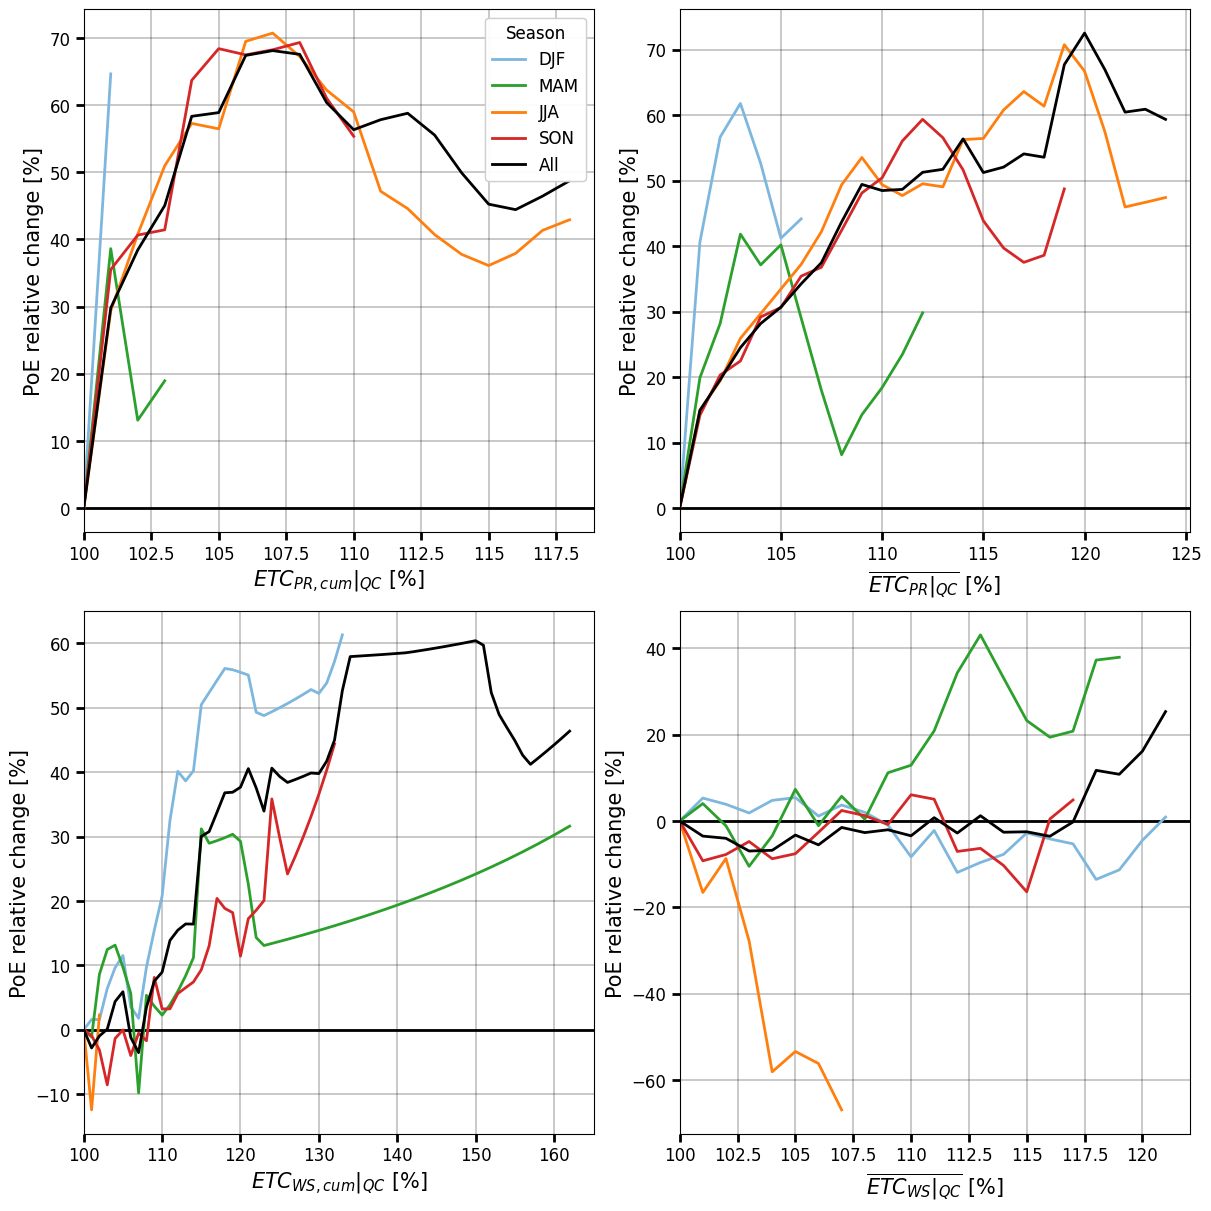

In [28]:
sim = 'UBD'
title = 'EC-Earth3-Veg'

common_metric_value = np.arange(thr_value, 5, 0.01)

fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

for params in plot_params:
    
    ax = axes[params["ax_index"]]
    ax.axhline(y=0, color='k', lw=2)
    
    for season, months in seasons.items():

        EETCs_hist = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if (
                EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim][k]['min_pressure_date']).month in months
            )
        ]
        EETCs_fut = [
            EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim_hist_fut[sim]]
            if (
                EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim_hist_fut[sim]][k]['min_pressure_date']).month in months
            )
        ]

        # Trie les valeurs
        EETCs_hist_sorted = np.sort(EETCs_hist)#[::-1]
        EETCs_fut_sorted = np.sort(EETCs_fut)#[::-1]

        # Calcule les poe correspondants
        poe_hist = 100 * (np.arange(1, len(EETCs_hist_sorted) + 1) / len(EETCs_hist_sorted))
        poe_fut = 100 * (np.arange(1, len(EETCs_fut_sorted) + 1) / len(EETCs_fut_sorted))
        
        poe_hist = poe_hist[::-1] #interp nécessite une grille croissante (EETCs_hist_sorted et common_metric_value), donc j'inverse l'ordre de tout, dont les POE
        poe_fut = poe_fut[::-1]

        # Interpole sur la grille commune
        interp_hist = np.interp(common_metric_value, EETCs_hist_sorted, poe_hist, right=np.nan)
        interp_fut = np.interp(common_metric_value, EETCs_fut_sorted, poe_fut, right=np.nan)

        # interp_hist = interp_hist
        # interp_fut  = interp_fut

        # Calcule la différence (futur - historique)
        diff = 100 * (interp_fut - interp_hist) / (interp_fut + interp_hist)

        ax.plot(common_metric_value * 100, diff, color=season_color[season], linestyle='-', linewidth=2)
        
    EETCs_hist = [
        EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
        for k in EETC_dict[sim]
        if EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
    ]
    
    EETCs_fut = [
        EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
        for k in EETC_dict[sim_hist_fut[sim]]
        if EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
    ]

    # Trie les valeurs
    EETCs_hist_sorted = np.sort(EETCs_hist)#[::-1]
    EETCs_fut_sorted = np.sort(EETCs_fut)#[::-1]

    # Calcule les poe correspondants
    poe_hist = 100 * (np.arange(1, len(EETCs_hist_sorted) + 1) / len(EETCs_hist_sorted))
    poe_fut = 100 * (np.arange(1, len(EETCs_fut_sorted) + 1) / len(EETCs_fut_sorted))
    
    poe_hist = poe_hist[::-1] #interp nécessite une grille croissante (EETCs_hist_sorted et common_metric_value), donc j'inverse l'ordre de tout, dont les POE
    poe_fut = poe_fut[::-1]

    # Interpole sur la grille commune
    interp_hist = np.interp(common_metric_value, EETCs_hist_sorted, poe_hist, right=np.nan)
    interp_fut = np.interp(common_metric_value, EETCs_fut_sorted, poe_fut, right=np.nan)

    # interp_hist = interp_hist
    # interp_fut  = interp_fut

    # Calcule la différence (futur - historique)
    diff = 100 * (interp_fut - interp_hist) / (interp_fut + interp_hist)

    ax.plot(common_metric_value * 100, diff, label='-', c='k', linewidth=2)
        
    ax.set_xlabel(params["label"], fontsize=15)
    ax.set_xlim(100, None)
    # ax.set_xscale('log')
    ax.set_ylabel("PoE relative change [%]", fontsize=15)
    # ax.set_ylim(-0, 0.3)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    if params["ax_index"] == (0, 0):
        season_handles = [
            Line2D([0], [0], color=season_color[season], linestyle='-', linewidth=2, label=season)
            for season in seasons]
    
        season_handles.append(
        Line2D([0], [0], color='k', linestyle='-', linewidth=2, label='All'))
        
        legend1 = ax.legend(handles=season_handles, title='Season', loc='best', fontsize=12, title_fontsize=12)
    
        ax.add_artist(legend1)
        
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')

# plt.savefig('/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/POE_diff_UBD_fut_vs_hist_season.png', dpi=70, bbox_inches='tight', transparent=True)

#### MPI-ESM1-2-HR

##### PoE historique vs future échelle log

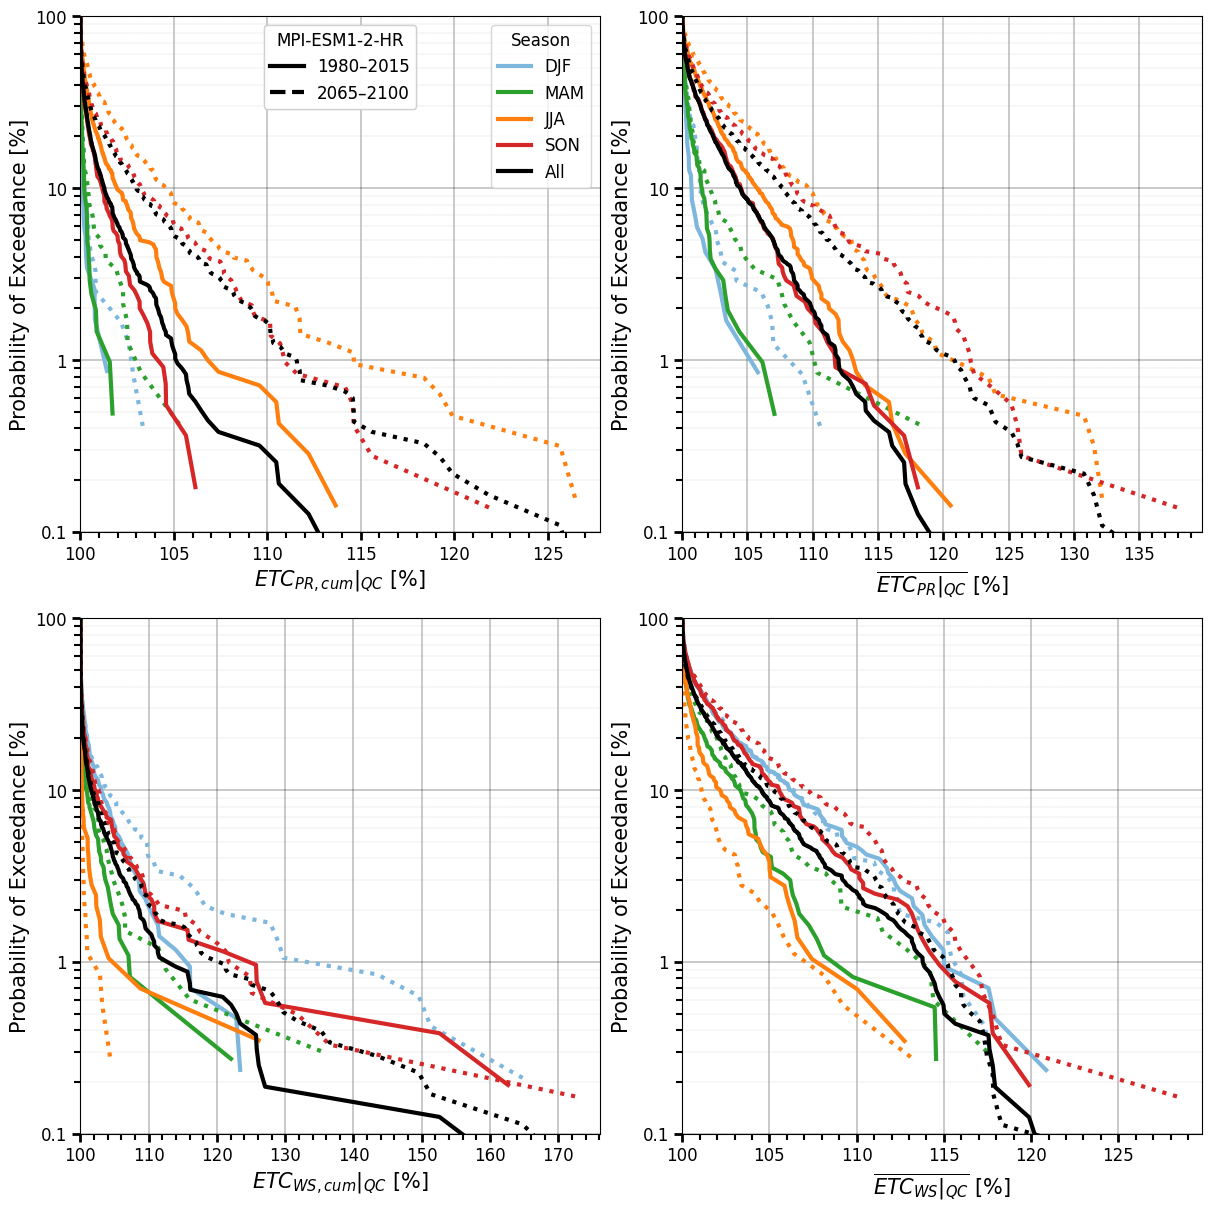

In [29]:
sim = 'UBE'
title = 'MPI-ESM1-2-HR'

fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

for params in plot_params:
    ax = axes[params["ax_index"]]
                
    for season, months in seasons.items():

        EETCs_hist = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if (
                EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim][k]['min_pressure_date']).month in months
            )
        ]
        EETCs_fut = [
            EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim_hist_fut[sim]]
            if (
                EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim_hist_fut[sim]][k]['min_pressure_date']).month in months
            )
        ]

        # Sort values for probability of exceedance
        sorted_vals_hist = np.sort(EETCs_hist)[::-1]  # Sort in descending order
        sorted_vals_fut  = np.sort(EETCs_fut)[::-1]
        
        prob_exceedance_hist = np.arange(1, len(sorted_vals_hist) + 1) / len(sorted_vals_hist)  # Calculate exceedance probability
        prob_exceedance_fut  = np.arange(1, len(sorted_vals_fut) + 1) / len(sorted_vals_fut)
        
        ax.plot(sorted_vals_hist * 100, prob_exceedance_hist * 100, color=season_color[season], linestyle='-', label=None, linewidth=3)
        ax.plot(sorted_vals_fut * 100, prob_exceedance_fut * 100, color=season_color[season], linestyle=':', label=None, linewidth=3)
  
    EETCs_hist = [
        EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
        for k in EETC_dict[sim]
        if EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
    ]
    EETCs_fut = [
        EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
        for k in EETC_dict[sim_hist_fut[sim]]
        if EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
    ]

    # Sort values for probability of exceedance
    sorted_vals_hist = np.sort(EETCs_hist)[::-1]  # Sort in descending order
    sorted_vals_fut  = np.sort(EETCs_fut)[::-1]
    
    prob_exceedance_hist = np.arange(1, len(sorted_vals_hist) + 1) / len(sorted_vals_hist)  # Calculate exceedance probability
    prob_exceedance_fut  = np.arange(1, len(sorted_vals_fut) + 1) / len(sorted_vals_fut)
    
    ax.plot(sorted_vals_hist * 100, prob_exceedance_hist * 100, color='k', linestyle='-', label=None, linewidth=3)
    ax.plot(sorted_vals_fut * 100, prob_exceedance_fut * 100, color='k', linestyle=':', label=None, linewidth=3)
    
    ax.set_xlim(100, None)
    ax.set_ylim(0.1, 100)  # Set y-axis limits to stop at 10^0
    ax.set_yscale('log')  # Set y-axis to logarithmic scale
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    ax.set_xlabel(params["label"], fontsize=15)
    ax.set_ylabel("Probability of Exceedance [%]", fontsize=15)
    # ax.set_title(params["label"], fontsize=15)

    if params["ax_index"] == (0, 0):
        # Légende 1 : saisons
        season_handles = [
            Line2D([0], [0], color=season_color[season], linestyle='-', linewidth=3, label=season)
            for season in seasons]
    
        season_handles.append(
        Line2D([0], [0], color='k', linestyle='-', linewidth=3, label='All'))
        
        legend1 = ax.legend(handles=season_handles, title='Season', loc='upper right', fontsize=12, title_fontsize=12)
    
        # Légende 2 : périodes temporelles
        style_handles = [
            Line2D([0], [0], color='k', linestyle='-', linewidth=3, label='1980–2015'),
            Line2D([0], [0], color='k', linestyle='--', linewidth=3, label='2065–2100'),
        ]
        legend2 = ax.legend(handles=style_handles, title=title, loc='upper center', fontsize=12, title_fontsize=12)
    
        # Ajoute les deux légendes à l’axe
        ax.add_artist(legend1)
        ax.add_artist(legend2)

    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.minorticks_on()
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')
    ax.grid(True, which='minor', axis='y', linestyle='--', linewidth=0.2)

# fig.suptitle(f"Probability of Exceedance of the strongest ETCs over Québec — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)
# plt.savefig(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/POE_UBD_fut_vs_hist_season.png', dpi=70, bbox_inches='tight', transparent=True)

##### Changement dans le futur de la probabilité d'excéder un seuil de métrique

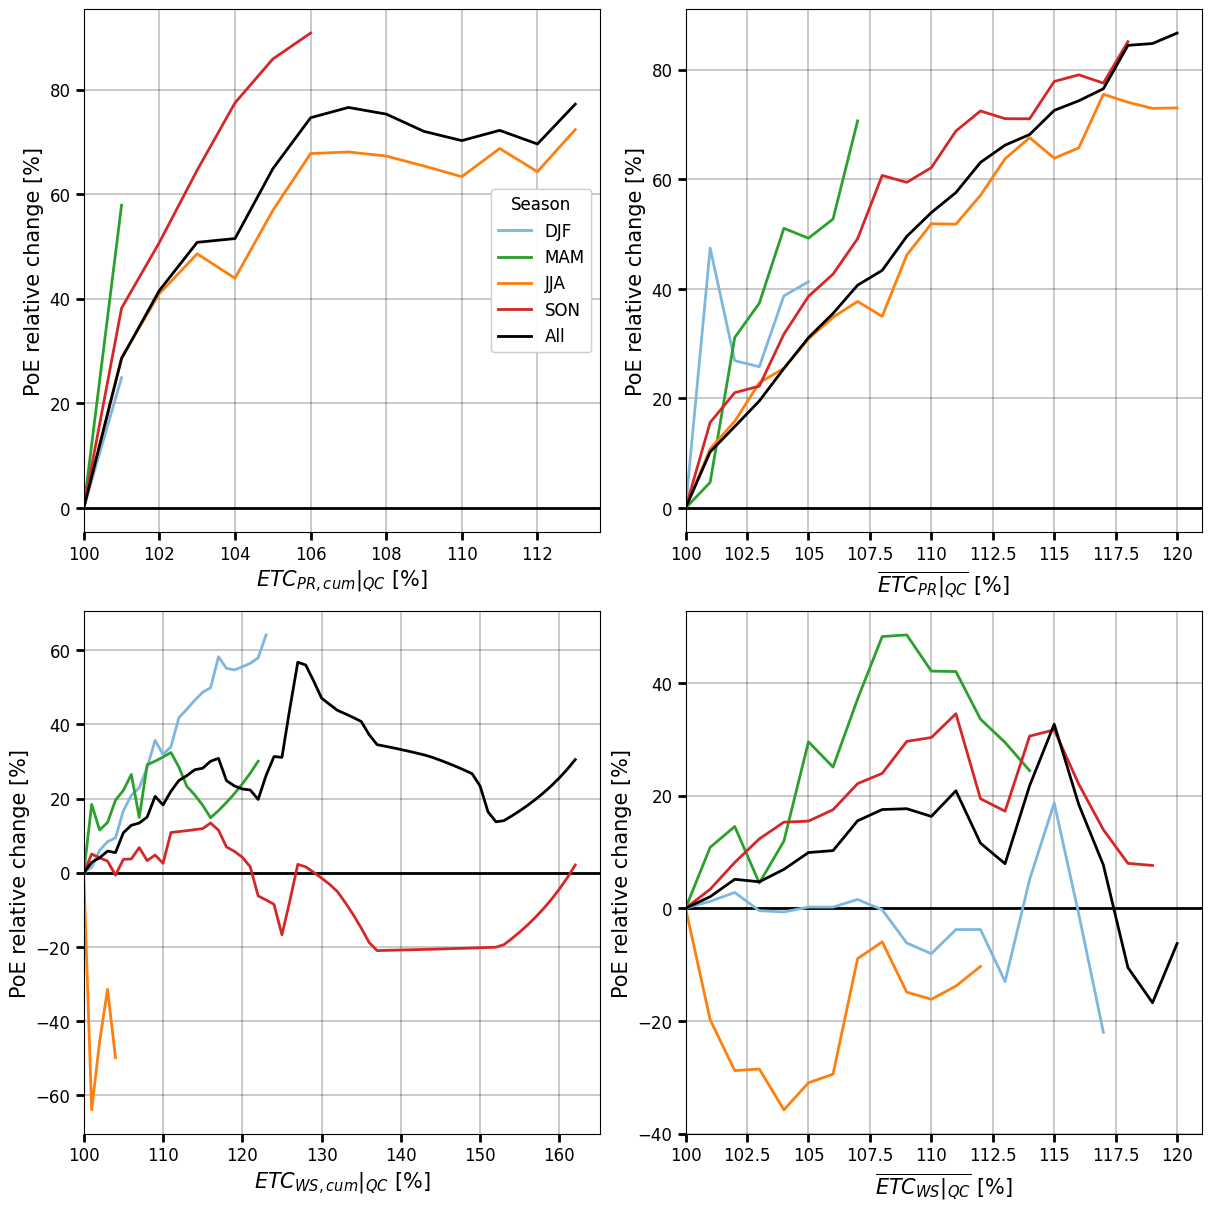

In [30]:
sim = 'UBE'
title = 'MPI-ESM1-2-HR'

common_metric_value = np.arange(thr_value, 5, 0.01)

fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

for params in plot_params:
    
    ax = axes[params["ax_index"]]
    ax.axhline(y=0, color='k', lw=2)
    
    for season, months in seasons.items():

        EETCs_hist = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if (
                EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim][k]['min_pressure_date']).month in months
            )
        ]
        EETCs_fut = [
            EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim_hist_fut[sim]]
            if (
                EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim_hist_fut[sim]][k]['min_pressure_date']).month in months
            )
        ]

        # Trie les valeurs
        EETCs_hist_sorted = np.sort(EETCs_hist)#[::-1]
        EETCs_fut_sorted = np.sort(EETCs_fut)#[::-1]

        # Calcule les poe correspondants
        poe_hist = 100 * (np.arange(1, len(EETCs_hist_sorted) + 1) / len(EETCs_hist_sorted))
        poe_fut = 100 * (np.arange(1, len(EETCs_fut_sorted) + 1) / len(EETCs_fut_sorted))
        
        poe_hist = poe_hist[::-1] #interp nécessite une grille croissante (EETCs_hist_sorted et common_metric_value), donc j'inverse l'ordre de tout, dont les POE
        poe_fut = poe_fut[::-1]

        # Interpole sur la grille commune
        interp_hist = np.interp(common_metric_value, EETCs_hist_sorted, poe_hist, right=np.nan)
        interp_fut = np.interp(common_metric_value, EETCs_fut_sorted, poe_fut, right=np.nan)

        # interp_hist = interp_hist
        # interp_fut  = interp_fut

        # Calcule la différence (futur - historique)
        diff = 100 * (interp_fut - interp_hist) / (interp_fut + interp_hist)

        ax.plot(common_metric_value * 100, diff, color=season_color[season], linestyle='-', linewidth=2)
        
    EETCs_hist = [
        EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
        for k in EETC_dict[sim]
        if EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
    ]
    
    EETCs_fut = [
        EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
        for k in EETC_dict[sim_hist_fut[sim]]
        if EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
    ]

    # Trie les valeurs
    EETCs_hist_sorted = np.sort(EETCs_hist)#[::-1]
    EETCs_fut_sorted = np.sort(EETCs_fut)#[::-1]

    # Calcule les poe correspondants
    poe_hist = 100 * (np.arange(1, len(EETCs_hist_sorted) + 1) / len(EETCs_hist_sorted))
    poe_fut = 100 * (np.arange(1, len(EETCs_fut_sorted) + 1) / len(EETCs_fut_sorted))
    
    poe_hist = poe_hist[::-1] #interp nécessite une grille croissante (EETCs_hist_sorted et common_metric_value), donc j'inverse l'ordre de tout, dont les POE
    poe_fut = poe_fut[::-1]

    # Interpole sur la grille commune
    interp_hist = np.interp(common_metric_value, EETCs_hist_sorted, poe_hist, right=np.nan)
    interp_fut = np.interp(common_metric_value, EETCs_fut_sorted, poe_fut, right=np.nan)

    # interp_hist = interp_hist
    # interp_fut  = interp_fut

    # Calcule la différence (futur - historique)
    diff = 100 * (interp_fut - interp_hist) / (interp_fut + interp_hist)

    ax.plot(common_metric_value * 100, diff, label='-', c='k', linewidth=2)
        
    ax.set_xlabel(params["label"], fontsize=15)
    ax.set_xlim(100, None)
    # ax.set_xscale('log')
    ax.set_ylabel("PoE relative change [%]", fontsize=15)
    # ax.set_ylim(-0, 0.3)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    if params["ax_index"] == (0, 0):
        season_handles = [
            Line2D([0], [0], color=season_color[season], linestyle='-', linewidth=2, label=season)
            for season in seasons]
    
        season_handles.append(
        Line2D([0], [0], color='k', linestyle='-', linewidth=2, label='All'))
        
        legend1 = ax.legend(handles=season_handles, title='Season', loc='best', fontsize=12, title_fontsize=12)
    
        ax.add_artist(legend1)
        
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')

# plt.savefig('/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/POE_diff_UBD_fut_vs_hist_season.png', dpi=70, bbox_inches='tight', transparent=True)

#### MIROC6

##### PoE historique vs future échelle log

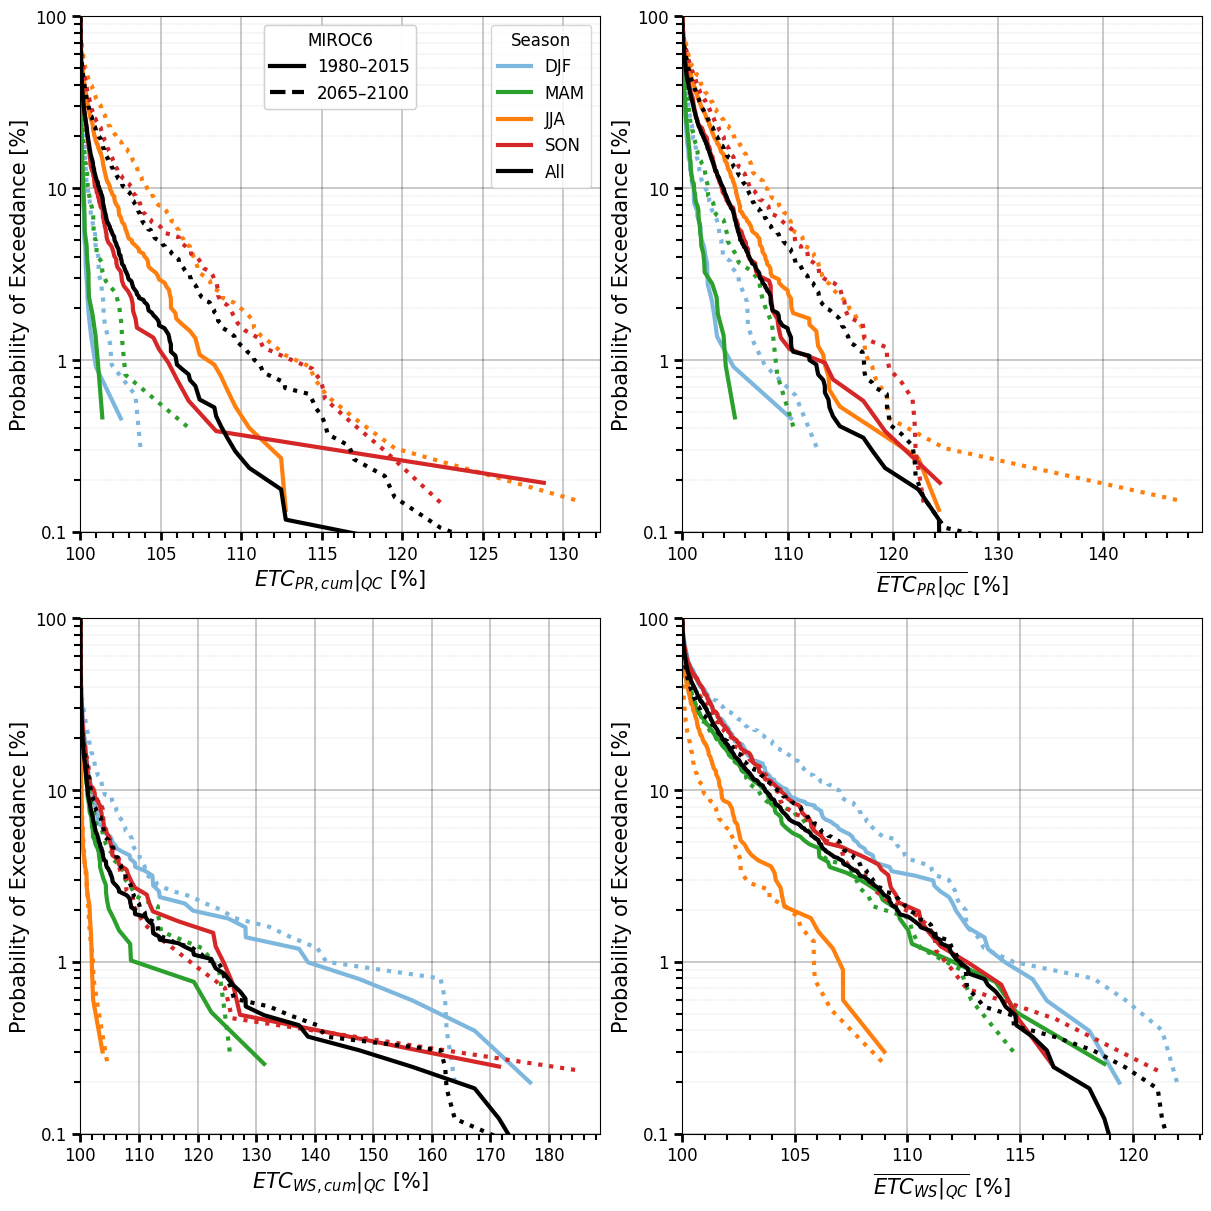

In [31]:
sim = 'UBF'
title = 'MIROC6'

fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

for params in plot_params:
    ax = axes[params["ax_index"]]
                
    for season, months in seasons.items():

        EETCs_hist = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if (
                EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim][k]['min_pressure_date']).month in months
            )
        ]
        EETCs_fut = [
            EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim_hist_fut[sim]]
            if (
                EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim_hist_fut[sim]][k]['min_pressure_date']).month in months
            )
        ]

        # Sort values for probability of exceedance
        sorted_vals_hist = np.sort(EETCs_hist)[::-1]  # Sort in descending order
        sorted_vals_fut  = np.sort(EETCs_fut)[::-1]
        
        prob_exceedance_hist = np.arange(1, len(sorted_vals_hist) + 1) / len(sorted_vals_hist)  # Calculate exceedance probability
        prob_exceedance_fut  = np.arange(1, len(sorted_vals_fut) + 1) / len(sorted_vals_fut)
        
        ax.plot(sorted_vals_hist * 100, prob_exceedance_hist * 100, color=season_color[season], linestyle='-', label=None, linewidth=3)
        ax.plot(sorted_vals_fut * 100, prob_exceedance_fut * 100, color=season_color[season], linestyle=':', label=None, linewidth=3)
  
    EETCs_hist = [
        EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
        for k in EETC_dict[sim]
        if EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
    ]
    EETCs_fut = [
        EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
        for k in EETC_dict[sim_hist_fut[sim]]
        if EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
    ]

    # Sort values for probability of exceedance
    sorted_vals_hist = np.sort(EETCs_hist)[::-1]  # Sort in descending order
    sorted_vals_fut  = np.sort(EETCs_fut)[::-1]
    
    prob_exceedance_hist = np.arange(1, len(sorted_vals_hist) + 1) / len(sorted_vals_hist)  # Calculate exceedance probability
    prob_exceedance_fut  = np.arange(1, len(sorted_vals_fut) + 1) / len(sorted_vals_fut)
    
    ax.plot(sorted_vals_hist * 100, prob_exceedance_hist * 100, color='k', linestyle='-', label=None, linewidth=3)
    ax.plot(sorted_vals_fut * 100, prob_exceedance_fut * 100, color='k', linestyle=':', label=None, linewidth=3)
    
    ax.set_xlim(100, None)
    ax.set_ylim(0.1, 100)  # Set y-axis limits to stop at 10^0
    ax.set_yscale('log')  # Set y-axis to logarithmic scale
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    ax.set_xlabel(params["label"], fontsize=15)
    ax.set_ylabel("Probability of Exceedance [%]", fontsize=15)
    # ax.set_title(params["label"], fontsize=15)

    if params["ax_index"] == (0, 0):
        # Légende 1 : saisons
        season_handles = [
            Line2D([0], [0], color=season_color[season], linestyle='-', linewidth=3, label=season)
            for season in seasons]
    
        season_handles.append(
        Line2D([0], [0], color='k', linestyle='-', linewidth=3, label='All'))
        
        legend1 = ax.legend(handles=season_handles, title='Season', loc='upper right', fontsize=12, title_fontsize=12)
    
        # Légende 2 : périodes temporelles
        style_handles = [
            Line2D([0], [0], color='k', linestyle='-', linewidth=3, label='1980–2015'),
            Line2D([0], [0], color='k', linestyle='--', linewidth=3, label='2065–2100'),
        ]
        legend2 = ax.legend(handles=style_handles, title=title, loc='upper center', fontsize=12, title_fontsize=12)
    
        # Ajoute les deux légendes à l’axe
        ax.add_artist(legend1)
        ax.add_artist(legend2)

    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.minorticks_on()
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')
    ax.grid(True, which='minor', axis='y', linestyle='--', linewidth=0.2)

# fig.suptitle(f"Probability of Exceedance of the strongest ETCs over Québec — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)
# plt.savefig(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/POE_UBD_fut_vs_hist_season.png', dpi=70, bbox_inches='tight', transparent=True)

##### Changement dans le futur de la probabilité d'excéder un seuil de métrique

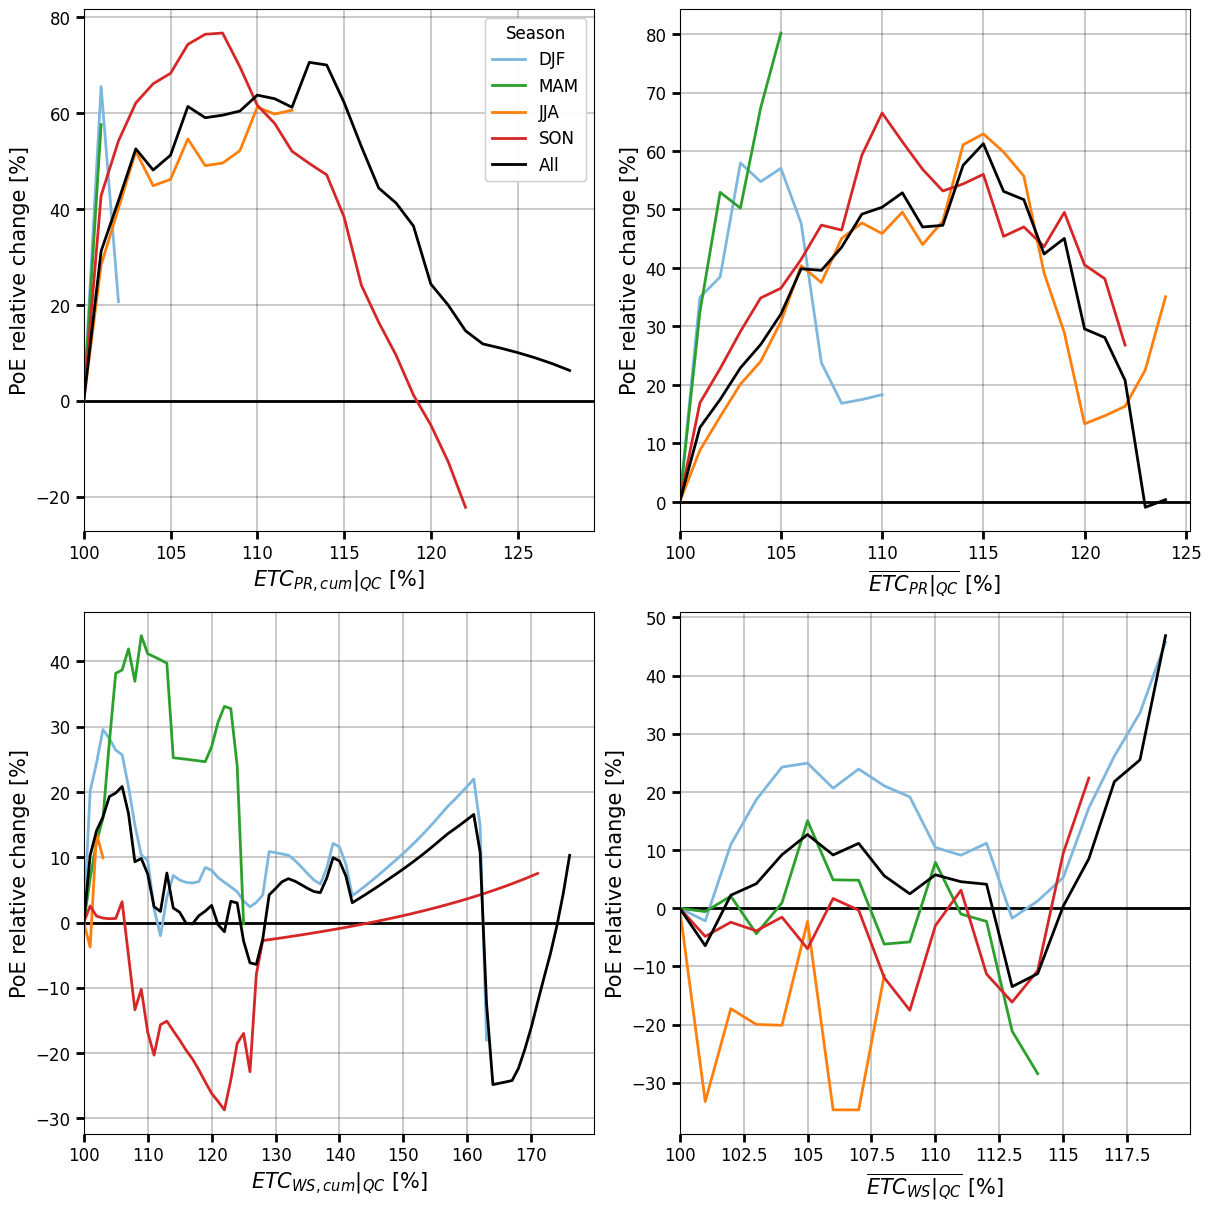

In [32]:
sim = 'UBF'
title = 'MIROC6'

common_metric_value = np.arange(thr_value, 5, 0.01)

fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

for params in plot_params:
    
    ax = axes[params["ax_index"]]
    ax.axhline(y=0, color='k', lw=2)
    
    for season, months in seasons.items():

        EETCs_hist = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if (
                EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim][k]['min_pressure_date']).month in months
            )
        ]
        EETCs_fut = [
            EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim_hist_fut[sim]]
            if (
                EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim_hist_fut[sim]][k]['min_pressure_date']).month in months
            )
        ]

        # Trie les valeurs
        EETCs_hist_sorted = np.sort(EETCs_hist)#[::-1]
        EETCs_fut_sorted = np.sort(EETCs_fut)#[::-1]

        # Calcule les poe correspondants
        poe_hist = 100 * (np.arange(1, len(EETCs_hist_sorted) + 1) / len(EETCs_hist_sorted))
        poe_fut = 100 * (np.arange(1, len(EETCs_fut_sorted) + 1) / len(EETCs_fut_sorted))
        
        poe_hist = poe_hist[::-1] #interp nécessite une grille croissante (EETCs_hist_sorted et common_metric_value), donc j'inverse l'ordre de tout, dont les POE
        poe_fut = poe_fut[::-1]

        # Interpole sur la grille commune
        interp_hist = np.interp(common_metric_value, EETCs_hist_sorted, poe_hist, right=np.nan)
        interp_fut = np.interp(common_metric_value, EETCs_fut_sorted, poe_fut, right=np.nan)

        # interp_hist = interp_hist
        # interp_fut  = interp_fut

        # Calcule la différence (futur - historique)
        diff = 100 * (interp_fut - interp_hist) / (interp_fut + interp_hist)

        ax.plot(common_metric_value * 100, diff, color=season_color[season], linestyle='-', linewidth=2)
        
    EETCs_hist = [
        EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
        for k in EETC_dict[sim]
        if EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
    ]
    
    EETCs_fut = [
        EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values
        for k in EETC_dict[sim_hist_fut[sim]]
        if EETC_dict[sim_hist_fut[sim]][k][params["var"]].sel(quantile=quantile).values > thr_value
    ]

    # Trie les valeurs
    EETCs_hist_sorted = np.sort(EETCs_hist)#[::-1]
    EETCs_fut_sorted = np.sort(EETCs_fut)#[::-1]

    # Calcule les poe correspondants
    poe_hist = 100 * (np.arange(1, len(EETCs_hist_sorted) + 1) / len(EETCs_hist_sorted))
    poe_fut = 100 * (np.arange(1, len(EETCs_fut_sorted) + 1) / len(EETCs_fut_sorted))
    
    poe_hist = poe_hist[::-1] #interp nécessite une grille croissante (EETCs_hist_sorted et common_metric_value), donc j'inverse l'ordre de tout, dont les POE
    poe_fut = poe_fut[::-1]

    # Interpole sur la grille commune
    interp_hist = np.interp(common_metric_value, EETCs_hist_sorted, poe_hist, right=np.nan)
    interp_fut = np.interp(common_metric_value, EETCs_fut_sorted, poe_fut, right=np.nan)

    # interp_hist = interp_hist
    # interp_fut  = interp_fut

    # Calcule la différence (futur - historique)
    diff = 100 * (interp_fut - interp_hist) / (interp_fut + interp_hist)

    ax.plot(common_metric_value * 100, diff, label='-', c='k', linewidth=2)
        
    ax.set_xlabel(params["label"], fontsize=15)
    ax.set_xlim(100, None)
    # ax.set_xscale('log')
    ax.set_ylabel("PoE relative change [%]", fontsize=15)
    # ax.set_ylim(-0, 0.3)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    if params["ax_index"] == (0, 0):
        season_handles = [
            Line2D([0], [0], color=season_color[season], linestyle='-', linewidth=2, label=season)
            for season in seasons]
    
        season_handles.append(
        Line2D([0], [0], color='k', linestyle='-', linewidth=2, label='All'))
        
        legend1 = ax.legend(handles=season_handles, title='Season', loc='best', fontsize=12, title_fontsize=12)
    
        ax.add_artist(legend1)
        
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')

# plt.savefig('/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/POE_diff_UBD_fut_vs_hist_season.png', dpi=70, bbox_inches='tight', transparent=True)